# 🔐 Système de Classification des Articles de Sécurité
### Projet Data Science Complet — Analyse, Visualisation & Modélisation

---

**Objectif :** Classifier automatiquement des articles de presse tunisiens selon leur catégorie de sécurité, à partir de leurs titres, tags et descriptions.

| Catégorie | Signification |
|-----------|---------------|
| 0 | Article non-sécuritaire (général) |
| 1 | Drogue / Stupéfiants |
| 2 | Criminalité / Délinquance |
| 3 | Braquages / Vols |
| 4 | Autres incidents sécuritaires |

---

## 📦 0. Imports & Configuration

In [1]:
# ─── Standard & Data ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# ─── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch

# ─── NLP ───────────────────────────────────────────────────────────────────────
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer

# ─── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score
)
# Models
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier

import joblib

# ─── Palette & Style ───────────────────────────────────────────────────────────
PALETTE = {
    'primary':   '#2D6A9F',
    'secondary': '#E8533F',
    'accent':    '#27AE60',
    'warning':   '#F39C12',
    'purple':    '#8E44AD',
    'dark':      '#2C3E50',
    'light':     '#ECF0F1'
}
CAT_COLORS = [
    PALETTE['primary'], PALETTE['secondary'], PALETTE['accent'],
    PALETTE['warning'], PALETTE['purple']
]
CAT_LABELS = {
    0: 'Général (0)',
    1: 'Drogue (1)',
    2: 'Criminalité (2)',
    3: 'Braquages (3)',
    4: 'Autres agressions. (4)'
}

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

FILE_PATH = 'articles_all.csv'
print('✅ Imports réussis')

✅ Imports réussis


---
## 📊 1. Compréhension des Données (EDA)

### 1.1 Chargement & Aperçu général

In [2]:
df_raw = pd.read_csv(FILE_PATH, sep=';', encoding='utf-8')

print('=' * 60)
print(f'  📁 Fichier : {FILE_PATH}')
print(f'  📐 Dimensions : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes')
print('=' * 60)
df_raw.head()

  📁 Fichier : articles_all.csv
  📐 Dimensions : 4,001 lignes × 7 colonnes


,source,url,title,date,description,tags,label
0,webdo.tn,https://www.webdo.tn/fr/actualite/divers/ce-me...,Ce médecin français explique les bienfaits cac...,mardi 3 mars 2026 09:10,La harissa n’est pas seulement un condiment qu...,harissa|Tunisie,NaN
1,webdo.tn,https://www.webdo.tn/fr/actualite/divers/ancie...,"Ancien maire de la Marsa, Slim Meherzi n’est plus",samedi 21 février 2026 10:39,"Nous apprenons que le docteur Slim Meherzi, an...",Décès|Marsa|Slim Meherzi,NaN
2,webdo.tn,https://www.webdo.tn/fr/actualite/divers/my-oo...,My Ooredoo sacrée « Produit de l’Année Tunisie...,mardi 17 février 2026 10:33,L’application My Ooredoo a été élue « Produit ...,ooredoo|produit de l'année|Tunisie,NaN
3,webdo.tn,https://www.webdo.tn/fr/actualite/divers/mahdi...,"Mahdia : Un million de dinars saisis, trois pe...",vendredi 13 février 2026 15:49,Le parquet près le Tribunal de première instan...,devises|justice|saisie|Tunisie,NaN
4,webdo.tn,https://www.webdo.tn/fr/actualite/divers/abus-...,Abus sexuels sur un enfant de 3 ans : Le princ...,vendredi 13 février 2026 13:09,Treize jours après la révélation d’une affaire...,abus sexuels|crèche|Enfant|justice|Tunisie,4.0


### 1.2 Description des colonnes

In [3]:
col_desc = pd.DataFrame({
    'Colonne':      df_raw.columns,
    'Type':         df_raw.dtypes.values,
    'Non-Nuls':     df_raw.notna().sum().values,
    'Valeurs nulles': df_raw.isnull().sum().values,
    '% Manquant':   (df_raw.isnull().mean() * 100).round(2).values,
    'Exemple':      [str(df_raw[c].dropna().iloc[0])[:60] if df_raw[c].notna().any() else 'N/A'
                     for c in df_raw.columns]
})

desc_map = {
    'source':      'Nom du site web source (ex: kapitalis.com)',
    'url':         'URL complète de l\'article',
    'title':       'Titre de l\'article (feature principale)',
    'date':        'Date de publication (format texte français)',
    'description': 'Corps/résumé de l\'article',
    'tags':        'Mots-clés séparés par | (ex: drogue|Tunis)',
    'label':       'Catégorie de sécurité (0-4), NaN = non étiqueté'
}
col_desc['Description'] = col_desc['Colonne'].map(desc_map)
col_desc

,Colonne,Type,Non-Nuls,Valeurs nulles,% Manquant,Exemple,Description
0,source,str,4001,0,0.00,webdo.tn,Nom du site web source (ex: kapitalis.com)
1,url,str,4001,0,0.00,https://www.webdo.tn/fr/actualite/divers/ce-me...,URL complète de l'article
2,title,str,4000,1,0.02,Ce médecin français explique les bienfaits cac...,Titre de l'article (feature principale)
3,date,str,4000,1,0.02,mardi 3 mars 2026 09:10,Date de publication (format texte français)
4,description,str,3997,4,0.10,La harissa n’est pas seulement un condiment qu...,Corps/résumé de l'article
5,tags,str,3881,120,3.00,harissa|Tunisie,Mots-clés séparés par | (ex: drogue|Tunis)
6,label,float64,148,3853,96.30,4.0,"Catégorie de sécurité (0-4), NaN = non étiqueté"


### 1.3 Analyse des valeurs manquantes & doublons

In [4]:
print('🔍 ANALYSE DES ANOMALIES')
print('─' * 50)

duplicates = df_raw.duplicated().sum()
dup_url    = df_raw['url'].duplicated().sum()
dup_title  = df_raw['title'].dropna().duplicated().sum()

print(f'  Doublons complets       : {duplicates}')
print(f'  URLs dupliquées         : {dup_url}')
print(f'  Titres dupliqués        : {dup_title}')
print()

total = len(df_raw)
labeled = df_raw['label'].notna().sum()
unlabeled = df_raw['label'].isna().sum()

print(f'  Total articles          : {total:,}')
print(f'  Articles étiquetés      : {labeled}  ({labeled/total*100:.1f}%)')
print(f'  Articles non-étiquetés  : {unlabeled:,}  ({unlabeled/total*100:.1f}%)')
print()

print('  Distribution des étiquettes :')
for v, cnt in df_raw['label'].value_counts(dropna=False).items():
    lbl = CAT_LABELS.get(int(v), 'Non étiqueté') if pd.notna(v) else 'Non étiqueté (NaN)'
    print(f'    Label {str(v):>5} → {cnt:>5} articles  ({cnt/total*100:.1f}%)')

print()
print('  Sources :')
print(df_raw['source'].value_counts().to_string())

🔍 ANALYSE DES ANOMALIES
──────────────────────────────────────────────────
  Doublons complets       : 109
  URLs dupliquées         : 109
  Titres dupliqués        : 113

  Total articles          : 4,001
  Articles étiquetés      : 148  (3.7%)
  Articles non-étiquetés  : 3,853  (96.3%)

  Distribution des étiquettes :
    Label   nan →  3853 articles  (96.3%)
    Label   1.0 →    60 articles  (1.5%)
    Label   2.0 →    53 articles  (1.3%)
    Label   3.0 →    21 articles  (0.5%)
    Label   4.0 →    14 articles  (0.3%)

  Sources :
source
kapitalis.com     3342
webdo.tn           266
letemps.news       215
mosaiquefm.net     178


### 1.4 Insights sur le texte

In [5]:
df_info = df_raw.copy()
df_info['title_len']       = df_info['title'].fillna('').apply(len)
df_info['desc_len']        = df_info['description'].fillna('').apply(len)
df_info['title_words']     = df_info['title'].fillna('').apply(lambda x: len(x.split()))
df_info['nb_tags']         = df_info['tags'].fillna('').apply(lambda x: len(x.split('|')) if x else 0)

print('📏 STATISTIQUES TEXTUELLES')
print('─' * 50)
stats = df_info[['title_len', 'title_words', 'desc_len', 'nb_tags']].describe().round(1)
stats.index = ['Nombre', 'Moyenne', 'Std', 'Min', '25%', '50%', '75%', 'Max']
stats.columns = ['Long. titre (car.)', 'Mots/titre', 'Long. description (car.)', 'Nb tags']
print(stats.to_string())

📏 STATISTIQUES TEXTUELLES
──────────────────────────────────────────────────
         Long. titre (car.)  Mots/titre  Long. description (car.)  Nb tags
Nombre               4001.0      4001.0                    4001.0   4001.0
Moyenne                65.7        11.1                    1438.1      5.3
Std                    13.7         2.5                    1484.3      2.0
Min                     0.0         0.0                       0.0      0.0
25%                    57.0         9.0                     691.0      4.0
50%                    65.0        11.0                     955.0      5.0
75%                    75.0        13.0                    1545.0      7.0
Max                   139.0        22.0                   18917.0     14.0


---
## 📈 2. Visualisation des Données

### 2.1 Distribution des sources & étiquettes

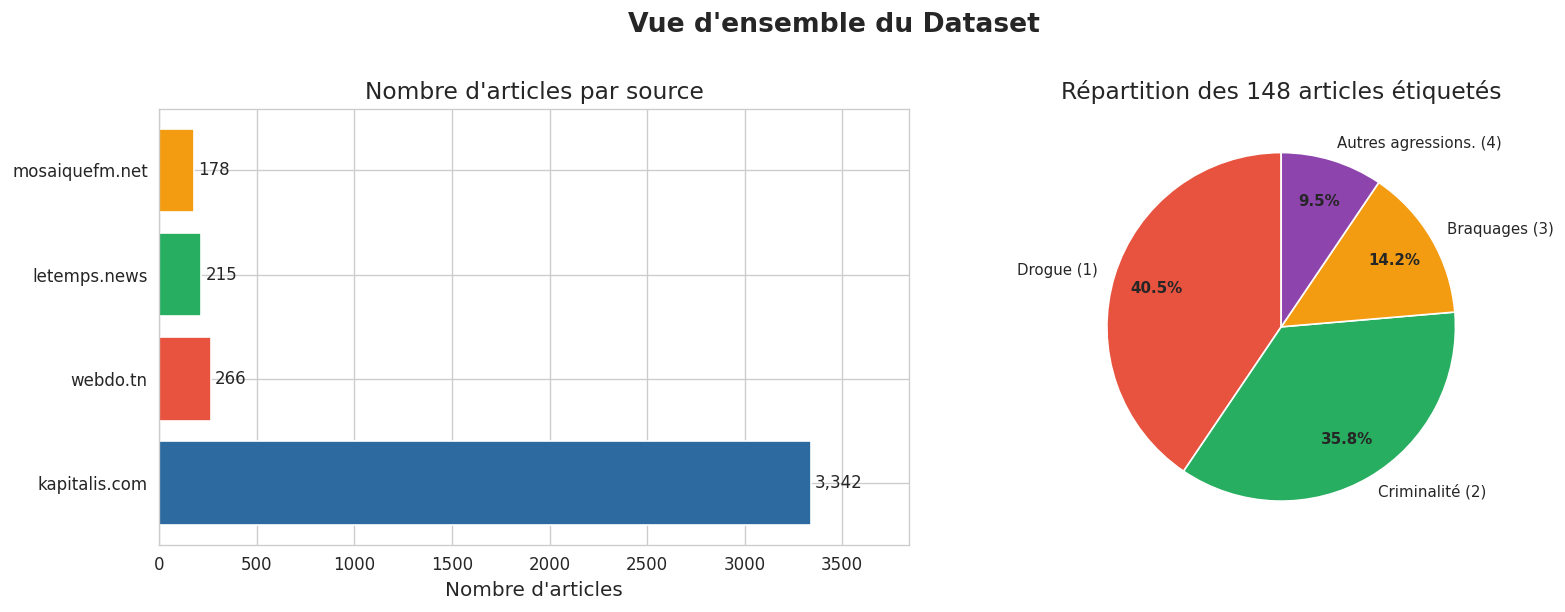

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Vue d\'ensemble du Dataset', fontsize=16, fontweight='bold', y=1.01)

# ── Sources ──
ax = axes[0]
src_counts = df_raw['source'].value_counts()
bars = ax.barh(src_counts.index, src_counts.values,
               color=[PALETTE['primary'], PALETTE['secondary'],
                      PALETTE['accent'], PALETTE['warning']])
for bar, val in zip(bars, src_counts.values):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)
ax.set_title('Nombre d\'articles par source')
ax.set_xlabel('Nombre d\'articles')
ax.set_xlim(0, src_counts.max() * 1.15)

# ── Étiquettes (labeled only) ──
ax2 = axes[1]
lbl_counts = df_raw['label'].dropna().value_counts().sort_index()
labels_text = [CAT_LABELS.get(int(k), str(k)) for k in lbl_counts.index]
wedges, texts, autotexts = ax2.pie(
    lbl_counts.values,
    labels=labels_text,
    colors=CAT_COLORS[1:],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_fontweight('bold')
ax2.set_title('Répartition des 148 articles étiquetés')

plt.tight_layout()
plt.show()

### 2.2 Déséquilibre des classes (sur les 500 lignes d'entraînement)

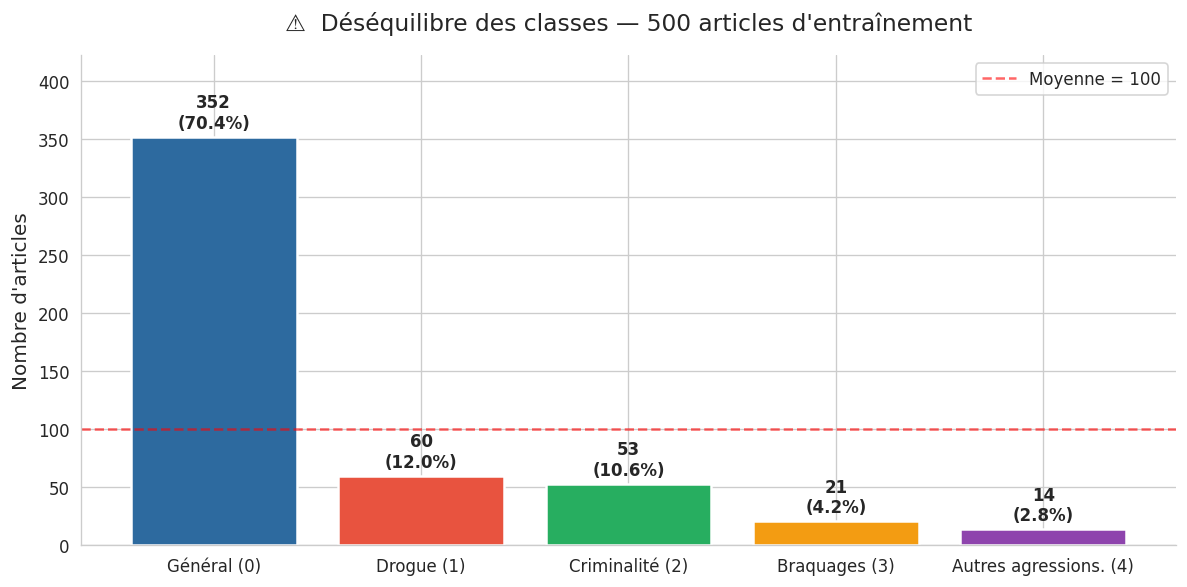


⚠️  Ratio Classe 0 / Classes sécuritaires : 2.4:1
   → Déséquilibre significatif — justifie l'usage de class_weight="balanced"


In [7]:
df_train = df_raw.head(500).copy()
df_train['label'] = df_train['label'].fillna(0).astype(int)
class_counts = df_train['label'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    [CAT_LABELS[k] for k in class_counts.index],
    class_counts.values,
    color=CAT_COLORS,
    edgecolor='white', linewidth=1.5
)

for bar, val in zip(bars, class_counts.values):
    pct = val / class_counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 4,
            f'{val}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('⚠️  Déséquilibre des classes — 500 articles d\'entraînement',
             fontsize=14, pad=15)
ax.set_ylabel('Nombre d\'articles')
ax.set_ylim(0, class_counts.max() * 1.2)
ax.axhline(y=class_counts.mean(), color='red', linestyle='--', alpha=0.6,
           label=f'Moyenne = {class_counts.mean():.0f}')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

ratio = class_counts[0] / class_counts[1:].sum()
print(f'\n⚠️  Ratio Classe 0 / Classes sécuritaires : {ratio:.1f}:1')
print(f'   → Déséquilibre significatif — justifie l\'usage de class_weight="balanced"')

### 2.3 Distribution temporelle des articles

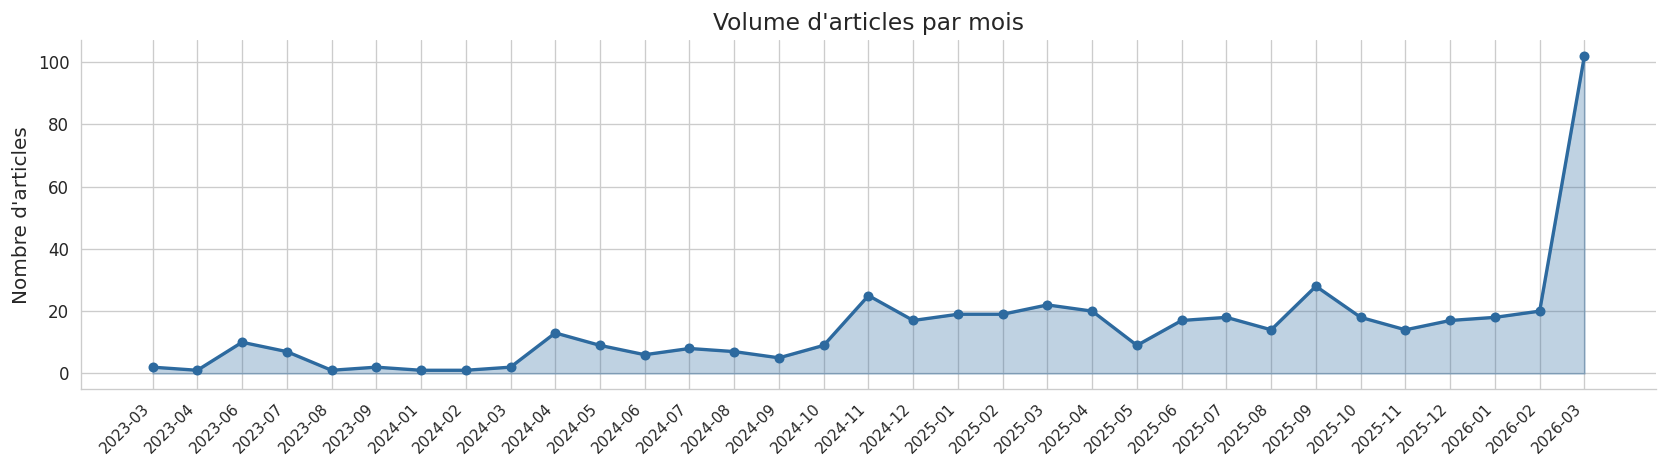

In [8]:
def extract_year_month(date_str):
    """Extract YYYY-MM from French date strings like 'mardi 3 mars 2026 09:10'"""
    month_map = {
        'janvier': '01', 'février': '02', 'mars': '03', 'avril': '04',
        'mai': '05', 'juin': '06', 'juillet': '07', 'août': '08',
        'septembre': '09', 'octobre': '10', 'novembre': '11', 'décembre': '12'
    }
    if pd.isna(date_str):
        return None
    for m_fr, m_num in month_map.items():
        if m_fr in str(date_str).lower():
            year_match = re.search(r'(\d{4})', str(date_str))
            if year_match:
                return f"{year_match.group(1)}-{m_num}"
    return None

df_raw['year_month'] = df_raw['date'].apply(extract_year_month)
monthly = df_raw['year_month'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(range(len(monthly)), monthly.values,
                alpha=0.3, color=PALETTE['primary'])
ax.plot(range(len(monthly)), monthly.values,
        color=PALETTE['primary'], linewidth=2, marker='o', markersize=5)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly.index, rotation=45, ha='right', fontsize=9)
ax.set_title('Volume d\'articles par mois')
ax.set_ylabel('Nombre d\'articles')
sns.despine()
plt.tight_layout()
plt.show()

### 2.4 Longueur des textes par catégorie

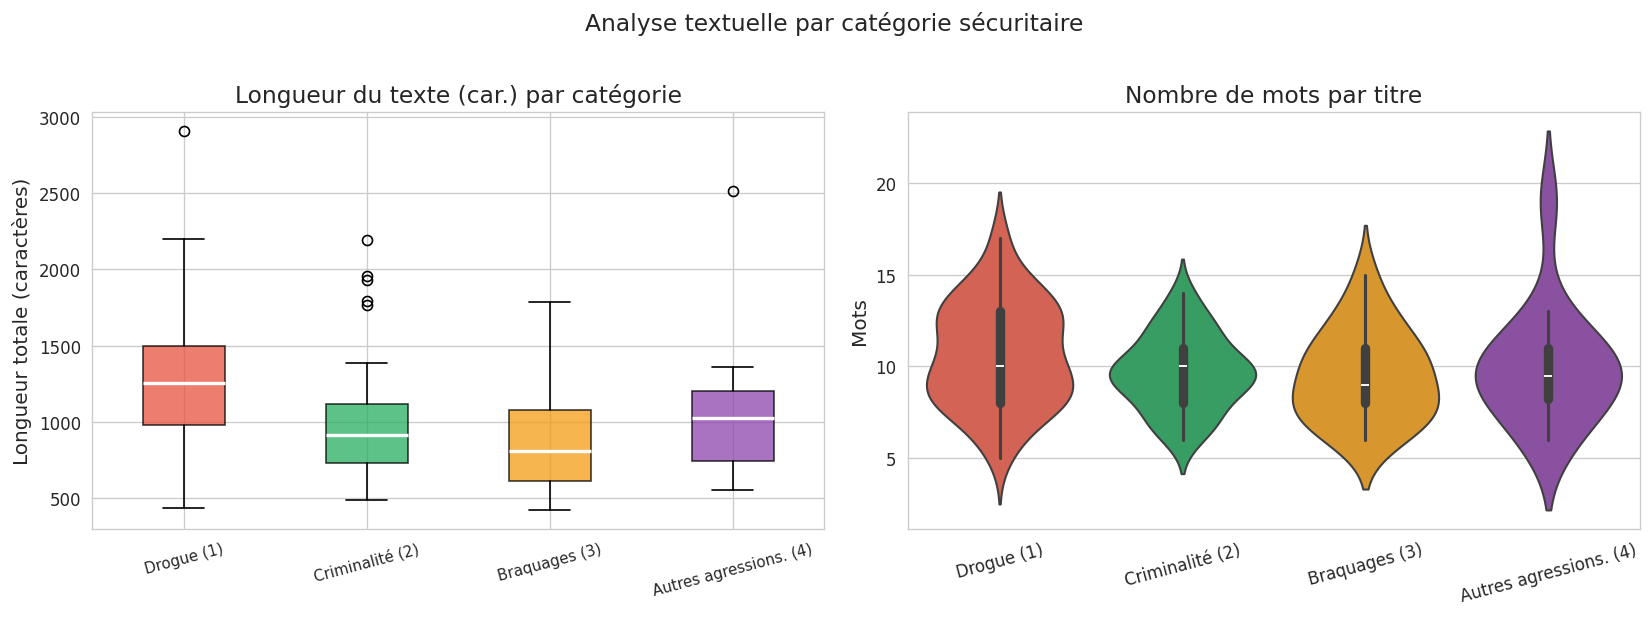

In [9]:
df_lbl = df_train[df_train['label'] > 0].copy()
df_lbl['text_len'] = (df_lbl['title'].fillna('') + ' ' +
                      df_lbl['tags'].fillna('') + ' ' +
                      df_lbl['description'].fillna('')).apply(len)
df_lbl['cat_label'] = df_lbl['label'].map(CAT_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
categories_order = [CAT_LABELS[i] for i in sorted(df_lbl['label'].unique())]
data_by_cat = [df_lbl[df_lbl['cat_label'] == c]['text_len'].values
               for c in categories_order]
bp = axes[0].boxplot(data_by_cat, patch_artist=True,
                     medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], CAT_COLORS[1:]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0].set_xticklabels(categories_order, rotation=15, fontsize=9)
axes[0].set_title('Longueur du texte (car.) par catégorie')
axes[0].set_ylabel('Longueur totale (caractères)')

# Nombre de mots par titre
df_lbl['title_words'] = df_lbl['title'].fillna('').apply(lambda x: len(x.split()))
sns.violinplot(data=df_lbl, x='cat_label', y='title_words',
               palette=CAT_COLORS[1:], ax=axes[1], order=categories_order, inner='box')
axes[1].set_title('Nombre de mots par titre')
axes[1].set_ylabel('Mots')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Analyse textuelle par catégorie sécuritaire', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2.5 Top tags par catégorie

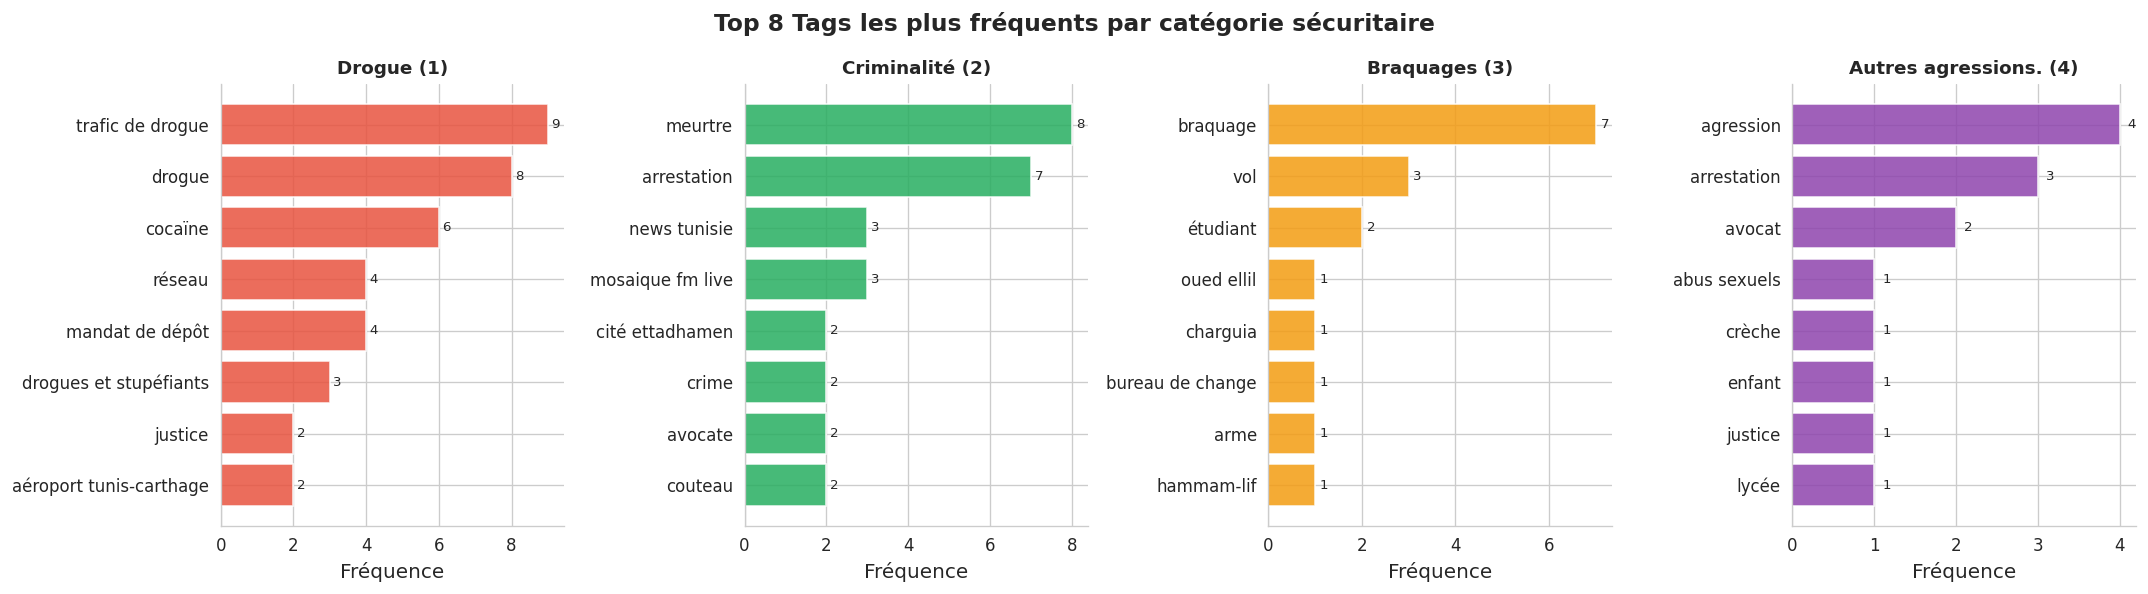

In [10]:
from collections import Counter

STOP_TAGS = {'tunisie', 'tunis', 'france', '', 'None'}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Top 8 Tags les plus fréquents par catégorie sécuritaire',
             fontsize=14, fontweight='bold')

for ax, cat in zip(axes, [1, 2, 3, 4]):
    subset = df_train[df_train['label'] == cat]['tags'].dropna()
    all_tags = []
    for t in subset:
        all_tags.extend([x.strip().lower() for x in str(t).split('|')
                         if x.strip().lower() not in STOP_TAGS])
    if not all_tags:
        ax.axis('off')
        continue
    top = Counter(all_tags).most_common(8)
    tags, counts = zip(*top)
    bars = ax.barh(tags[::-1], counts[::-1],
                   color=CAT_COLORS[cat], alpha=0.85)
    ax.set_title(CAT_LABELS[cat], fontsize=11, fontweight='bold')
    ax.set_xlabel('Fréquence')
    for bar, val in zip(bars, counts[::-1]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=8)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

---
## 🧹 3. Prétraitement des Données

### 3.1 Nettoyage

In [11]:
df = df_raw.head(500).copy()

# ── 1. Supprimer les doublons exacts ──
before = len(df)
df = df.drop_duplicates(subset=['title', 'description'], keep='first')
print(f'✂️  Doublons supprimés : {before - len(df)} lignes  ({before} → {len(df)})')

# ── 2. Remplissage des valeurs manquantes ──
df['title']       = df['title'].fillna('')
df['tags']        = df['tags'].fillna('')
df['description'] = df['description'].fillna('')

# ── 3. Label : NaN → 0 ──
df['label'] = df['label'].replace(['', ' ', None], np.nan)
df['label'] = df['label'].fillna(0).astype(int)

# ── 4. Construction du texte unifié ──
df['text'] = df['title'] + ' ' + df['tags'] + ' ' + df['description']

# ── 5. Nettoyage texte ──
def clean_text(text):
    text = re.sub(r'http\S+', '', text)           # URLs
    text = re.sub(r'[^\w\sàâäéèêëîïôùûüç-]', ' ', text)  # Ponctuation
    text = re.sub(r'\s+', ' ', text).strip()       # Espaces multiples
    return text.lower()

df['text_clean'] = df['text'].apply(clean_text)

print()
print('📊 Distribution finale (500 lignes nettoyées) :')
for k, v in df['label'].value_counts().sort_index().items():
    print(f'   Label {k} ({CAT_LABELS[k]:<20}) : {v} articles')
print(f'\n✅ Dataset prêt : {len(df)} lignes × {len(df.columns)} colonnes')

✂️  Doublons supprimés : 76 lignes  (500 → 424)

📊 Distribution finale (500 lignes nettoyées) :
   Label 0 (Général (0)         ) : 276 articles
   Label 1 (Drogue (1)          ) : 60 articles
   Label 2 (Criminalité (2)     ) : 53 articles
   Label 3 (Braquages (3)       ) : 21 articles
   Label 4 (Autres agressions. (4)) : 14 articles

✅ Dataset prêt : 424 lignes × 10 colonnes


### 3.2 Préparation Train / Test

In [12]:
try:
    nlp = spacy.load('fr_core_news_lg')
except OSError:
    nlp = spacy.load('fr_core_news_sm')
stop_words_french = list(nlp.Defaults.stop_words)

X = df['text_clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Train : {len(X_train)} articles  |  Test : {len(X_test)} articles')
print(f'   Stratification préservée :')
for split_name, split_y in [('Train', y_train), ('Test', y_test)]:
    dist = split_y.value_counts(normalize=True).sort_index()
    print(f'   {split_name}: ' + '  '.join([f'L{k}={v:.0%}' for k, v in dist.items()]))

✅ Train : 339 articles  |  Test : 85 articles
   Stratification préservée :
   Train: L0=65%  L1=14%  L2=12%  L3=5%  L4=3%
   Test: L0=65%  L1=14%  L2=13%  L3=5%  L4=4%


---
## 🤖 4. Comparaison des Modèles

### 4.1 Entraînement de 6 modèles

In [13]:
# ── Définition des modèles ──
models = {
    'LinearSVC (baseline)': LinearSVC(class_weight='balanced', C=1.0, random_state=42, max_iter=2000),
    'Logistic Regression':  LogisticRegression(class_weight='balanced', C=1.0, max_iter=1000, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Naive Bayes':          MultinomialNB(alpha=0.5),
    'KNN':                  KNeighborsClassifier(n_neighbors=5, metric='cosine'),
}

TFIDF_PARAMS = dict(
    ngram_range=(1, 2),
    max_features=10000,
    stop_words=stop_words_french
)

results = {}
cv_results = {}
print('🚀 Entraînement en cours...\n')

for name, clf in models.items():
    tfidf = TfidfVectorizer(**TFIDF_PARAMS)
    if name == 'Naive Bayes':
        # NB ne supporte pas les valeurs négatives — on utilise min_df
        tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=10000,
                                stop_words=stop_words_french, min_df=1)

    pipeline = Pipeline([('tfidf', tfidf), ('clf', clf)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    f1w  = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    f1m  = f1_score(y_test, y_pred, average='macro', zero_division=0)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)

    results[name] = {
        'Accuracy': round(acc, 4),
        'F1 Weighted': round(f1w, 4),
        'F1 Macro': round(f1m, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'pipeline': pipeline,
        'y_pred': y_pred
    }

    # 5-fold cross-validation (on full dataset)
    cv = cross_val_score(pipeline, X, y,
                         cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                         scoring='f1_weighted', n_jobs=-1)
    cv_results[name] = cv

    print(f'  ✅ {name:<25} Acc={acc:.3f}  F1w={f1w:.3f}  CV_F1={cv.mean():.3f}±{cv.std():.3f}')

print('\n🏁 Terminé !')

🚀 Entraînement en cours...

  ✅ LinearSVC (baseline)      Acc=0.812  F1w=0.807  CV_F1=0.814±0.040
  ✅ Logistic Regression       Acc=0.800  F1w=0.799  CV_F1=0.823±0.057
  ✅ Random Forest             Acc=0.706  F1w=0.649  CV_F1=0.709±0.033
  ✅ Gradient Boosting         Acc=0.753  F1w=0.733  CV_F1=0.774±0.036
  ✅ Naive Bayes               Acc=0.694  F1w=0.594  CV_F1=0.640±0.011
  ✅ KNN                       Acc=0.718  F1w=0.709  CV_F1=0.723±0.051

🏁 Terminé !


### 4.2 Tableau de comparaison

In [14]:
df_results = pd.DataFrame({
    name: {k: v for k, v in vals.items() if k not in ('pipeline', 'y_pred')}
    for name, vals in results.items()
}).T

df_results['CV F1 Mean'] = pd.Series({n: cv_results[n].mean().round(4) for n in cv_results})
df_results['CV F1 Std']  = pd.Series({n: cv_results[n].std().round(4)  for n in cv_results})

df_results = df_results.sort_values('F1 Weighted', ascending=False)
df_results.index.name = 'Modèle'

print('📊 COMPARAISON DES MODÈLES (triée par F1 Weighted)')
print('=' * 80)
print(df_results.drop(columns=['F1 Macro']).to_string())
print('=' * 80)
best_model_name = df_results.index[0]
print(f'\n🏆 Meilleur modèle : {best_model_name}')

📊 COMPARAISON DES MODÈLES (triée par F1 Weighted)
                      Accuracy  F1 Weighted  Precision  Recall  CV F1 Mean  CV F1 Std
Modèle                                                                               
LinearSVC (baseline)    0.8118       0.8066     0.8221  0.8118      0.8138     0.0405
Logistic Regression     0.8000       0.7987     0.8236  0.8000      0.8226     0.0566
Gradient Boosting       0.7529       0.7329     0.7268  0.7529      0.7738     0.0359
KNN                     0.7176       0.7085     0.7123  0.7176      0.7232     0.0506
Random Forest           0.7059       0.6490     0.6539  0.7059      0.7090     0.0326
Naive Bayes             0.6941       0.5939     0.5805  0.6941      0.6399     0.0108

🏆 Meilleur modèle : LinearSVC (baseline)


### 4.3 Visualisation comparative

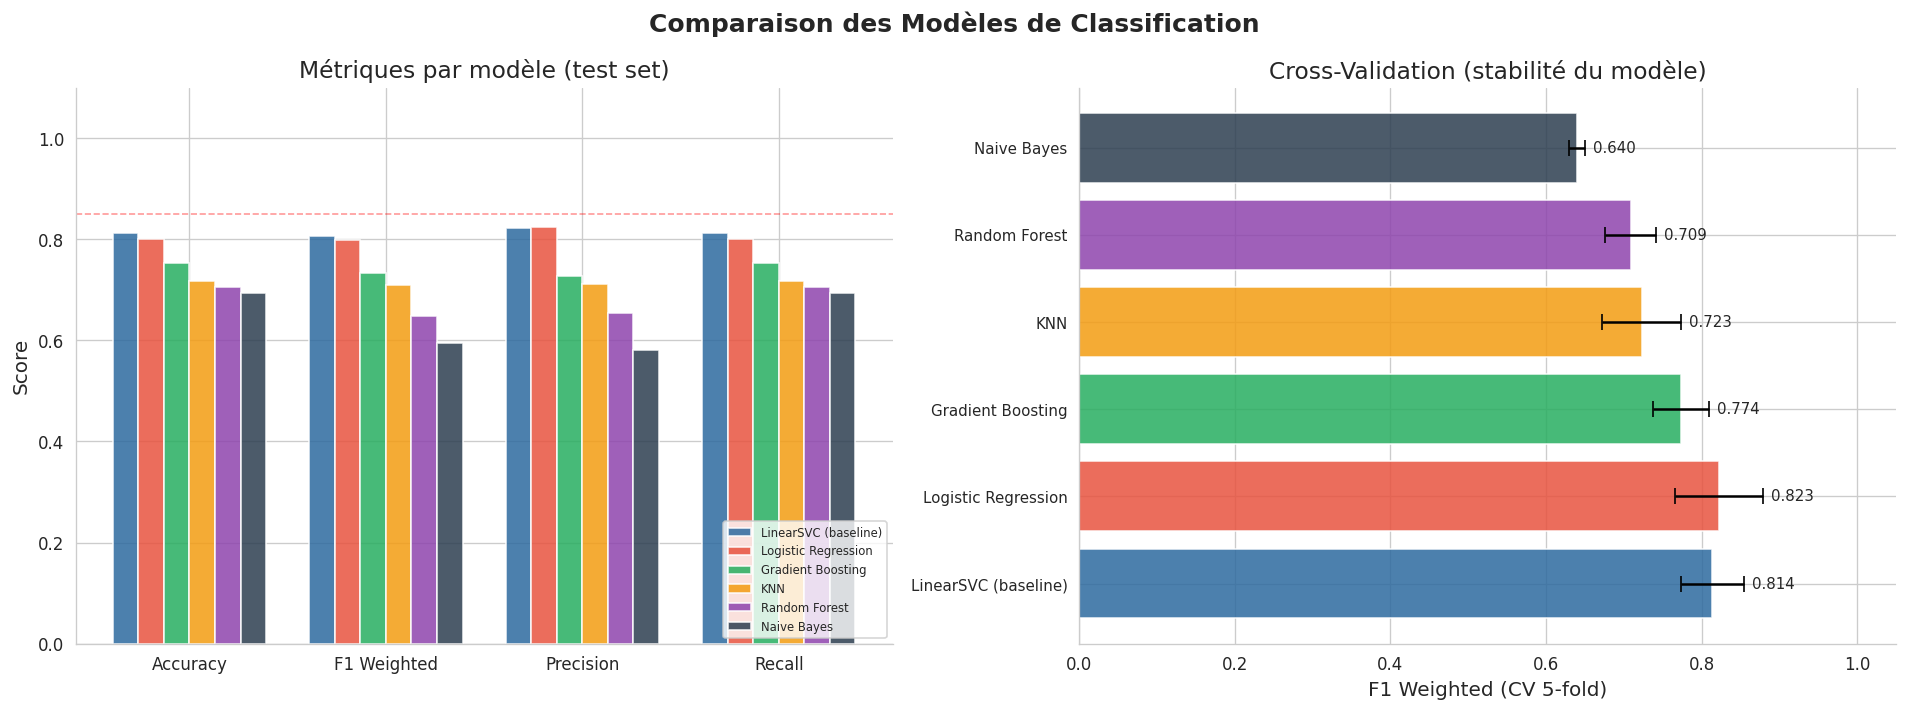

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparaison des Modèles de Classification', fontsize=15, fontweight='bold')

metrics = ['Accuracy', 'F1 Weighted', 'Precision', 'Recall']
x = np.arange(len(metrics))
width = 0.13
bar_colors = [PALETTE['primary'], PALETTE['secondary'], PALETTE['accent'],
              PALETTE['warning'], PALETTE['purple'], PALETTE['dark']]

ax1 = axes[0]
for i, (name, row) in enumerate(df_results.iterrows()):
    offset = (i - len(df_results)/2) * width + width/2
    bars = ax1.bar(x + offset, [row[m] for m in metrics],
                   width, label=name, color=bar_colors[i], alpha=0.85)

ax1.set_xticks(x)
ax1.set_xticklabels(metrics, fontsize=10)
ax1.set_ylabel('Score')
ax1.set_ylim(0, 1.1)
ax1.set_title('Métriques par modèle (test set)')
ax1.legend(fontsize=7, loc='lower right')
ax1.axhline(0.85, color='red', linestyle='--', alpha=0.4, linewidth=1)
sns.despine(ax=ax1)

# Cross-Validation
ax2 = axes[1]
cv_means = [cv_results[n].mean() for n in df_results.index]
cv_stds  = [cv_results[n].std()  for n in df_results.index]
bars = ax2.barh(
    range(len(df_results)), cv_means,
    xerr=cv_stds, color=bar_colors[:len(df_results)],
    alpha=0.85, capsize=5, edgecolor='white'
)
ax2.set_yticks(range(len(df_results)))
ax2.set_yticklabels(df_results.index, fontsize=9)
ax2.set_xlabel('F1 Weighted (CV 5-fold)')
ax2.set_title('Cross-Validation (stabilité du modèle)')
ax2.set_xlim(0, 1.05)
for i, (m, s) in enumerate(zip(cv_means, cv_stds)):
    ax2.text(m + s + 0.01, i, f'{m:.3f}', va='center', fontsize=9)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

### 4.4 Matrice de confusion du meilleur modèle

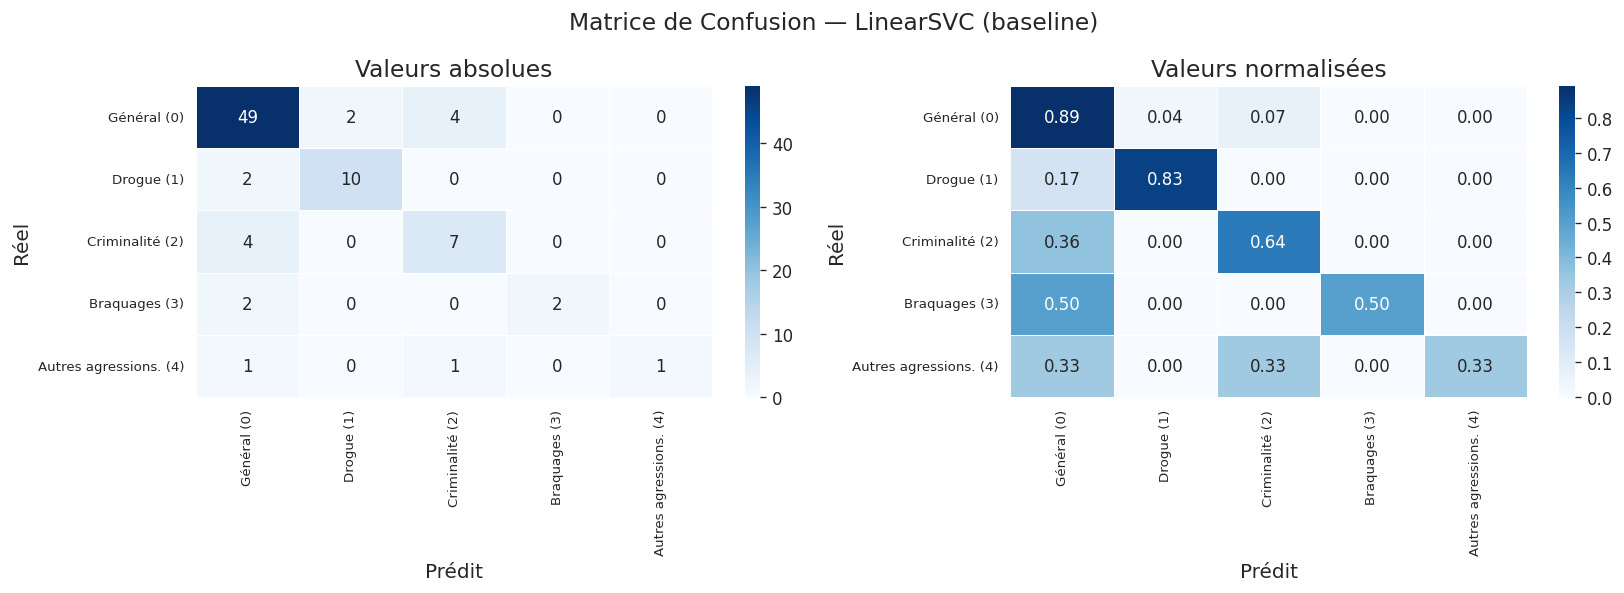


📋 Classification Report — LinearSVC (baseline) :
                        precision    recall  f1-score   support

           Général (0)       0.84      0.89      0.87        55
            Drogue (1)       0.83      0.83      0.83        12
       Criminalité (2)       0.58      0.64      0.61        11
         Braquages (3)       1.00      0.50      0.67         4
Autres agressions. (4)       1.00      0.33      0.50         3

              accuracy                           0.81        85
             macro avg       0.85      0.64      0.70        85
          weighted avg       0.82      0.81      0.81        85



In [16]:
best_pipeline = results[best_model_name]['pipeline']
best_pred     = results[best_model_name]['y_pred']

cm = confusion_matrix(y_test, best_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
labels = [CAT_LABELS[i] for i in sorted(y_test.unique())]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Matrice de Confusion — {best_model_name}', fontsize=14)

for ax, data, title, fmt in [
    (axes[0], cm,      'Valeurs absolues', 'd'),
    (axes[1], cm_norm, 'Valeurs normalisées', '.2f')
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                ax=ax, linewidths=0.5, linecolor='white',
                annot_kws={'size': 10})
    ax.set_title(title)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')
    ax.tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.show()

print(f'\n📋 Classification Report — {best_model_name} :')
print(classification_report(y_test, best_pred,
                             target_names=labels, zero_division=0))

### 4.5 Rapport détaillé par classe

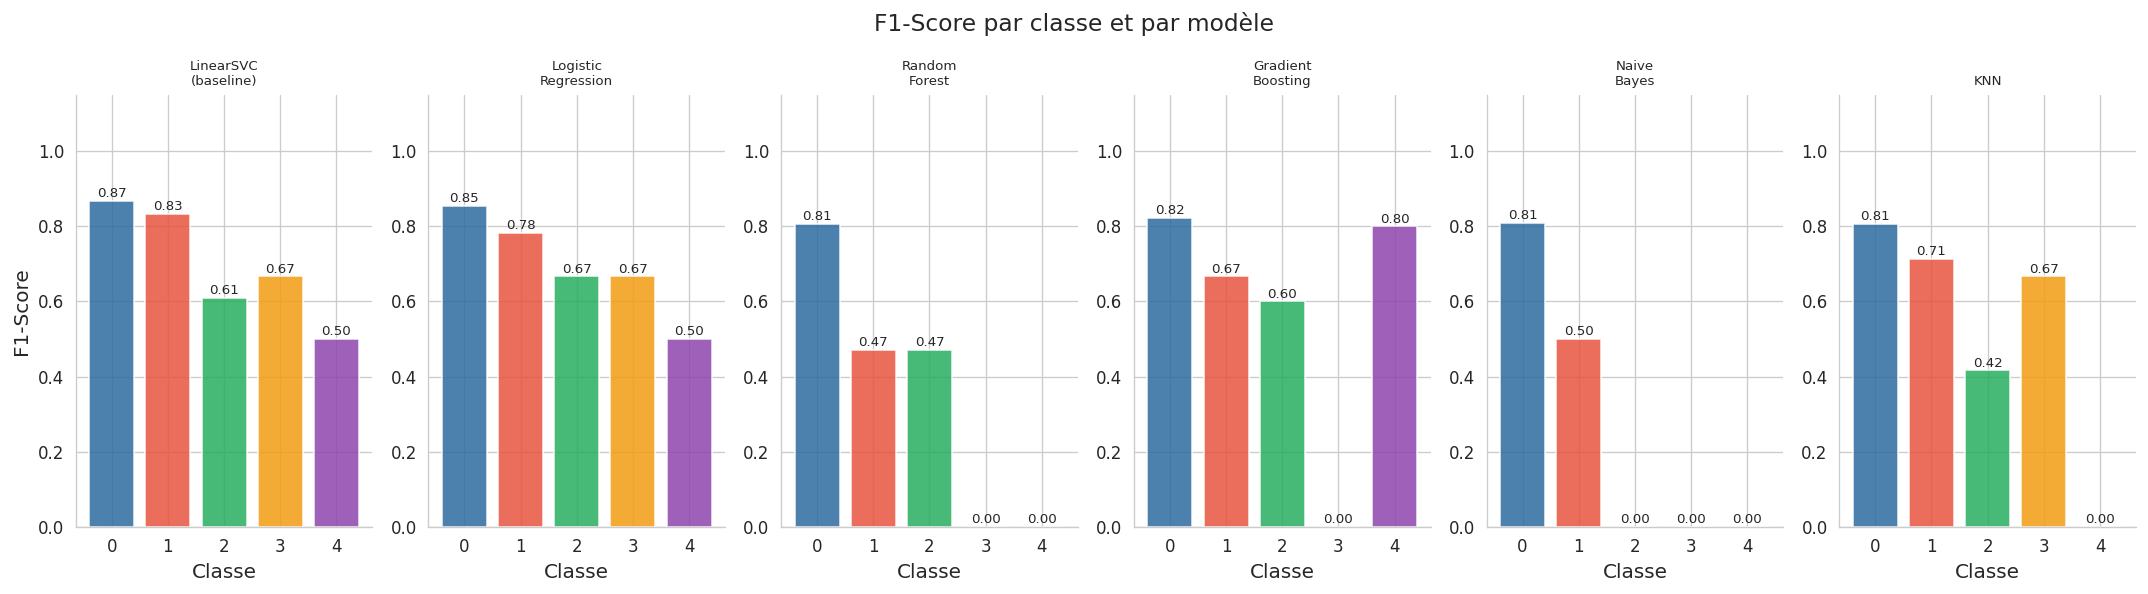

In [17]:
fig, axes = plt.subplots(1, len(results), figsize=(18, 5))
fig.suptitle('F1-Score par classe et par modèle', fontsize=14)

for ax, (name, vals) in zip(axes, results.items()):
    report = classification_report(y_test, vals['y_pred'],
                                   output_dict=True, zero_division=0)
    classes = [str(k) for k in sorted(y_test.unique())]
    f1s = [report[c]['f1-score'] for c in classes]
    bar_c = [CAT_COLORS[int(c)] for c in classes]
    bars = ax.bar(classes, f1s, color=bar_c, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', fontsize=8)
    ax.set_title(name.replace(' ', '\n'), fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.set_xlabel('Classe')
    if ax == axes[0]:
        ax.set_ylabel('F1-Score')
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

---
## 🔧 5. Modèle Final (Pipeline Original Conservé)

### 5.1 Ré-entraînement & sauvegarde

In [18]:
# ── Le modèle original (LinearSVC) — conservé tel quel ──
final_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=10000,
        stop_words=stop_words_french
    )),
    ('clf', LinearSVC(class_weight='balanced', C=1.0, random_state=42, max_iter=2000))
])

print('Entraînement en cours...')
final_pipeline.fit(X_train, y_train)

y_pred_final = final_pipeline.predict(X_test)
print('\nRAPPORT DE PERFORMANCE :')
print(classification_report(y_test, y_pred_final,
                             target_names=[CAT_LABELS[i] for i in sorted(y_test.unique())],
                             zero_division=0))

# Ré-entraîner sur les 500 lignes complètes
final_pipeline.fit(X, y)
model_filename = 'modele_securite_v2.joblib'
joblib.dump(final_pipeline, model_filename)
print(f'\nSuccès ! Modèle sauvegardé sous : {model_filename}')

# Test rapide
test_text = "Arrestation d'un dealer avec 500 comprimés de ecstasy à l'Aouina"
prediction = final_pipeline.predict([test_text])[0]
print(f"Test prediction: {test_text}")
print(f"  → Catégorie: {prediction} ({CAT_LABELS[prediction]})")

Entraînement en cours...

RAPPORT DE PERFORMANCE :
                        precision    recall  f1-score   support

           Général (0)       0.84      0.89      0.87        55
            Drogue (1)       0.83      0.83      0.83        12
       Criminalité (2)       0.58      0.64      0.61        11
         Braquages (3)       1.00      0.50      0.67         4
Autres agressions. (4)       1.00      0.33      0.50         3

              accuracy                           0.81        85
             macro avg       0.85      0.64      0.70        85
          weighted avg       0.82      0.81      0.81        85


Succès ! Modèle sauvegardé sous : modele_securite_v2.joblib
Test prediction: Arrestation d'un dealer avec 500 comprimés de ecstasy à l'Aouina
  → Catégorie: 1 (Drogue (1))


### 5.2 Application sur les articles non-étiquetés

In [19]:
import re as _re

model = joblib.load('modele_securite_v2.joblib')
df_all = pd.read_csv(FILE_PATH, sep=';', encoding='utf-8')
df_rest = df_all.iloc[500:].copy()

def extraire_date_evoluee(row):
    texte_source = f"{row['title']} {row['description']} {row.get('url', '')}"
    match = _re.search(r'(\d{2,4}[/-]\d{1,2}[/-]\d{2,4})', str(texte_source))
    return match.group(1) if match else 'Date inconnue'

results_pred = []
print('Analyse en cours...')
for _, row in df_rest.iterrows():
    texte = f"{row['title']} {row['tags']} {row['description']}"
    cat = model.predict([texte])[0]
    if cat > 0:
        doc = nlp(texte)
        lieux = list(set([ent.text for ent in doc.ents if ent.label_ == 'LOC']))
        results_pred.append({
            'titre':          str(row['title']),
            'categorie':      int(cat),
            'cat_label':      CAT_LABELS[int(cat)],
            'lieux_extraits': ', '.join(lieux),
            'date':           extraire_date_evoluee(row),
            'url':            row.get('url', '')
        })

df_final = pd.DataFrame(results_pred)
df_final.to_csv('analyse_propre.csv', index=False, sep=';', encoding='utf-8-sig')
print(f"Terminé ! {len(df_final)} articles sécuritaires détectés sur {len(df_rest)} articles.")
print(f"Fichier 'analyse_propre.csv' généré.")
print()
print('Distribution des catégories détectées :')
print(df_final['cat_label'].value_counts().to_string())

Analyse en cours...
Terminé ! 348 articles sécuritaires détectés sur 3501 articles.
Fichier 'analyse_propre.csv' généré.

Distribution des catégories détectées :
cat_label
Drogue (1)                225
Criminalité (2)            82
Braquages (3)              28
Autres agressions. (4)     13


---
## 💡 6. Analyse des Erreurs & Pistes d'Amélioration

### 6.1 Analyse des erreurs de classification

In [20]:
# Recharger le pipeline entraîné sur train set pour l'analyse des erreurs
eval_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=10000,
                              stop_words=stop_words_french)),
    ('clf', LinearSVC(class_weight='balanced', C=1.0, random_state=42, max_iter=2000))
])
eval_pipeline.fit(X_train, y_train)
y_eval_pred = eval_pipeline.predict(X_test)

# Exemples mal classifiés
X_test_df = X_test.reset_index(drop=True)
errors_df = pd.DataFrame({
    'texte':    X_test_df.str[:120],
    'réel':     y_test.reset_index(drop=True),
    'prédit':   y_eval_pred
})
errors = errors_df[errors_df['réel'] != errors_df['prédit']]

print(f'❌ Erreurs de classification : {len(errors)} / {len(y_test)} ({len(errors)/len(y_test)*100:.1f}%)')
print()
print('Exemples d\'erreurs :')
print(errors.head(10).to_string(index=False))

❌ Erreurs de classification : 16 / 85 (18.8%)

Exemples d'erreurs :
                                                                                                                   texte  réel  prédit
meurtre d une avocate à la manouba ses fils suspectés selon son neveux avocate crime manouba tunisie la région de manoub     0       2
tragédie à sousse un retraité italien assassiné dans sa maison de vacances expatriés paolo corsi sousse tunisie sousse l     2       0
sfax neuf plaintes contre un instituteur pour agression sexuelle le juge d instruction au tribunal de première instance      4       0
tunisie meurtre d un enfant de 4 ans enquête en cours et accusation de meurtre prémédité enfant enquête kasserine meurtr     0       2
mahdia de la cruauté d une mère envers ses propres enfants férid ben j ha porte-parole des tribunaux de monastir et mahd     4       2
ils semaient la terreur à ksar hellal ferid ben j ha porte-parole des tribunaux de mahdia et de monastir a indiqué dans   

### 6.2 Synthèse des recommandations